# Personal Gym Supplements RAG

Same RAGWire pipeline as Module 2 — different domain, different data, different system prompt.
This shows how little needs to change to go from finance to health.

**Model:** `gemini-2.5-flash` (Google) · **Embedding:** `gemini-embedding-001` (Google) · **Vector Store:** Qdrant Cloud

## 1. Setup and Ingest

In [47]:
from dotenv import load_dotenv
load_dotenv(override=True)

from ragwire import RAGWire, setup_logging
import ragwire

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)



1.2.8


In [60]:
rag = RAGWire('config_gemini_qdrant.yaml')

2026-05-15 00:43:48,151 - ragwire.core.pipeline - INFO - Loading configuration from config_gemini_qdrant.yaml
2026-05-15 00:43:48,951 - ragwire.core.pipeline - INFO - Document loader initialized
2026-05-15 00:43:48,960 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-05-15 00:43:50,853 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=google)
2026-05-15 00:43:52,573 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: health_metadata.yaml
2026-05-15 00:43:52,575 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=google, model=gemini-2.5-flash)
2026-05-15 00:43:53,105 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at https://fc9fdb5f-d3c8-41fe-bb65-07f2f779a04e.eu-central-1-0.aws.cloud.qdrant.io:6333
2026-05-15 00:43:54,013 - ragwire.core.pipeline - INFO - Using existing collection: health-rag-google-qdrant
2026-05-15 00:43:59,479 - ragwire.core.pipelin

In [62]:
rag.ingest_directory('../data/health_data')

2026-05-15 00:46:22,316 - ragwire.core.pipeline - INFO - Found 10 file(s) in ../data/health_data
2026-05-15 00:46:22,338 - ragwire.core.pipeline - INFO - Starting ingestion of 10 documents


Ingesting:   0%|          | 0/10 [00:00<?, ?file/s]

2026-05-15 00:46:23,891 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\health_data\02_Creatine_Supplementation_2024.pdf


Ingesting:  10%|█         | 1/10 [00:01<00:13,  1.53s/file]

2026-05-15 00:46:24,475 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\health_data\03_Vitamin_D_Performance_2024.pdf


...

Ingesting:  90%|█████████ | 9/10 [00:07<00:00,  1.24file/s]

2026-05-15 00:46:30,331 - ragwire.core.pipeline - INFO - Skipping (already ingested): ..\data\health_data\12_Protein_Supplementation_Review_2024.pdf


Ingesting: 100%|██████████| 10/10 [00:07<00:00,  1.25file/s]


2026-05-15 00:46:35,137 - ragwire.core.pipeline - INFO - Ingestion complete: 0/10 documents


{'total': 10,
 'processed': 0,
 'skipped': 10,
 'failed': 0,
 'chunks_created': 0,
 'errors': []}

## 2. Basic Retrieval

In [63]:
rag.retrieve("protein", top_k=3)

2026-05-15 00:46:43,638 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: protein...


[Document(metadata={'source': '..\\data\\health_data\\02_Creatine_Supplementation_2024.pdf', 'file_name': '02_Creatine_Supplementation_2024.pdf', 'file_type': 'pdf', 'file_hash': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5', 'chunk_id': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5_3', 'chunk_hash': 'b1b42514e16098adaae08545ef5c76dd3532786ebcbf4ce3334632243b7955f7', 'chunk_index': 3, 'total_chunks': 9, 'created_at': '2026-05-14T19:07:26.545803+00:00', 'title': 'effects of different dietary supplements combined with conditioning training on muscle strength, jump performance, sprint speed, and muscle mass in athletes: a systematic review and network meta-analysis', 'authors': ['beiwang deng', 'ruixiang yan', 'tianyuan he', 'gesheng lin', 'ting liu', 'wen chen', 'jiaxin he', 'duanying li'], 'publication_year': 2025, 'research_focus': ['dietary-supplements', 'conditioning-training', 'muscle-strength', 'jump-performance', 'sprint-speed', 'muscle-mas

In [64]:
rag.retrieve("what are the benefits of vitamin d?", top_k=3)

2026-05-15 00:46:45,238 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: what are the benefits of vitamin d?...


[Document(metadata={'source': '..\\data\\health_data\\02_Creatine_Supplementation_2024.pdf', 'file_name': '02_Creatine_Supplementation_2024.pdf', 'file_type': 'pdf', 'file_hash': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5', 'chunk_id': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5_3', 'chunk_hash': 'b1b42514e16098adaae08545ef5c76dd3532786ebcbf4ce3334632243b7955f7', 'chunk_index': 3, 'total_chunks': 9, 'created_at': '2026-05-14T19:07:26.545803+00:00', 'title': 'effects of different dietary supplements combined with conditioning training on muscle strength, jump performance, sprint speed, and muscle mass in athletes: a systematic review and network meta-analysis', 'authors': ['beiwang deng', 'ruixiang yan', 'tianyuan he', 'gesheng lin', 'ting liu', 'wen chen', 'jiaxin he', 'duanying li'], 'publication_year': 2025, 'research_focus': ['dietary-supplements', 'conditioning-training', 'muscle-strength', 'jump-performance', 'sprint-speed', 'muscle-mas

## 3. Agent

Same two tools from Module 2 (`get_filter_context`, `search_documents`).
The only difference: the system prompt is tuned for a health and fitness assistant.

In [ ]:
# from langchain.agents import create_agent
# from langchain.tools import tool
# from langchain.messages import HumanMessage
# from langchain_ollama import ChatOllama
# from langgraph.checkpoint.memory import InMemorySaver
# from langchain_google_genai import ChatGoogleGenerativeAI

# @tool
# def get_filter_context(query: str) -> str:
#     """Get available metadata fields, stored values, and filter suggestions for a query.

#     Call this before search_documents when the query involves a specific company,
#     year, or document type. Skip for purely semantic queries.
#     """
#     return rag.get_filter_context(query)

# @tool
# def search_documents(query: str, filters: Dict[str, Any] = {}):
#     """Search the document knowledge base for relevant information.

#     Args:
#         query: The search query
#         filters: Optional metadata filters from get_filter_context.
#     """

#     results = rag.retrieve(query=query, filters=filters or {})

#     if not results:
#         return "No relevant information is found!"
#     else:
#         return results 
    
# # model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

# agent = create_agent(
#     model=ChatGoogleGenerativeAI(model="gemini-2.5-flash"),
#     tools=[get_filter_context, search_documents],
#     system_prompt="""You are a helpful health and fitness assistant.
#                     For complex questions, break them down into simple sub-questions.
#                     Always use search_documents to retrieve information — never answer from general knowledge.
#                     Use get_filter_context before search_documents when the query involves specific metadata.
#                     Always cite the source document in your answer.""",
    
#     checkpointer=InMemorySaver(),
# )

# agent



NameError: name 'Dict' is not defined

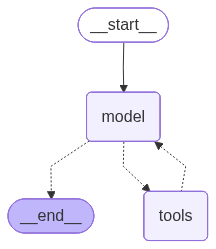

In [68]:
from typing import Dict, Any
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI


class SearchInput(BaseModel):
    query: str
    filters: Dict[str, Any] = Field(default_factory=dict)


@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)


@tool(args_schema=SearchInput)
def search_documents(
    query: str,
    filters: Dict[str, Any] = {}
):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(
        query=query,
        filters=filters or {}
    )

    if not results:
        return "No relevant information is found!"

    return "\n\n".join(
        [doc.page_content[:1000] for doc in results]
    )


agent = create_agent(
    model=ChatGoogleGenerativeAI(
        model="gemini-2.5-flash"
    ),

    tools=[
        get_filter_context,
        search_documents
    ],

    system_prompt="""
You are a helpful health and fitness assistant.

For complex questions, break them down into simple sub-questions.

Always use search_documents to retrieve information — never answer from general knowledge.

Use get_filter_context before search_documents when the query involves specific metadata.

Always cite the source document in your answer.
""",

    checkpointer=InMemorySaver(),
)

agent

## 4. Interactive Q&A

In [69]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.



2026-05-15 00:53:45,685 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: benefits of vitamin d...

Agent: Vitamin D supplementation has been associated with several benefits, particularly in athletic contexts:

*   **Improved 25(OH)D levels:** Vitamin D supplementation consistently increases 25(OH)D levels in the body (Rockwell et al., 2020; Żebrowska et al., 2020).
*   **Enhanced fat-free mass:** Studies have shown that vitamin D supplementation can enhance fat-free mass (Rockwell et al., 2020).
*   **Increased strength and power:** Some research indicates that vitamin D supplementation can lead to significant improvements in strength and power, affecting performance metrics such as the deadlift and vertical jump (Rockwell et al., 2020). However, a meta-analysis also suggested no clear benefits for muscular strength compared to other supplements like protein or creatine (Deng et al., Frontiers in Nutrition).
*   **Reduced muscle injury biomarkers:** Post-exercise vita